# Import and configurations

In [1]:
# Requirements

!pip install seqeval vaderSentiment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.3 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=1d1cd0717baaf7f501c1bdb6fd27c7e2f3842346868f35e56c23f317629af032
  Stored in directory: /root/.cache/pip/wheels/14/cf/a7/8f28ef376d707ff10e3922899482a2f23ef3002f8a952f47ac
Successfully built seqeval


In [2]:
# Libraries

import os
import re
import string
import warnings
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import nltk
import spacy
from nltk.tokenize import word_tokenize, TreebankWordTokenizer
from nltk.corpus import stopwords
from nltk.corpus import sentiwordnet as swn

from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Requirements

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("sentiwordnet")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package sentiwordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/sentiwordnet.zip.


True

In [4]:
# Requirements

!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-08-29 10:10:10--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-08-29 10:10:10--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-08-29 10:10:11--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [5]:
# SpaCy initialization

nlp = spacy.load("en_core_web_sm")

In [6]:
# Configurations

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
# Device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [8]:
# Drive mounting

drive.mount('/content/drive')
DATASET_PATH = "/content/drive/MyDrive/SII/Restaurants_Train_v2.csv"
#MODEL_PATH = "/content/drive/MyDrive/SII/bilstm_pretrained.pt"

Mounted at /content/drive


STUDY CASE: ATE/OTE

# Functions

In [9]:
# Creating BIO labels:

def create_bio_labels(sentence, aspects):
    spans = list(tokenizer.span_tokenize(sentence))
    tokens = [
        sentence[start:end]
        for start, end in spans
    ]
    labels = ["O"] * len(tokens)
    for aspect, aspect_start, aspect_end in aspects:
        aspect_tokens = []
        for i, (token_start, token_end) in enumerate(spans):
            overlap = (
                token_start < aspect_end
                and token_end > aspect_start
            )
            if overlap:
                aspect_tokens.append(i)
        if len(aspect_tokens) > 0:
            labels[aspect_tokens[0]] = "B-ASP"
            for idx in aspect_tokens[1:]:
                labels[idx] = "I-ASP"
    return tokens, labels

In [10]:
# Counting aspects:

def count_aspects(data):
    count = 0
    for sample in data:
        count += sum(
            1
            for label in sample["labels"]
            if label == "B-ASP"
        )
    return count

# Dataset loading and preparation

In [11]:
df = pd.read_csv(DATASET_PATH)
df.head()

,id,Sentence,Aspect Term,polarity,from,to
0,3121,But the staff was so horrible to us.,staff,negative,8,13
1,2777,"To be completely fair, the only redeeming fact...",food,positive,57,61
2,1634,"The food is uniformly exceptional, with a very...",food,positive,4,8
3,1634,"The food is uniformly exceptional, with a very...",kitchen,positive,55,62
4,1634,"The food is uniformly exceptional, with a very...",menu,neutral,141,145


In [12]:
# Grouping aspect terms with same sentence

grouped = []

for sentence, group in df.groupby("Sentence"):
    aspects = []
    for _, row in group.iterrows():
        aspects.append(
            (
                row["Aspect Term"],
                int(row["from"]),
                int(row["to"])
            )
        )
    grouped.append(
        {
            "sentence": sentence,
            "aspects": aspects
        }
    )

print(f"Number of reviews: {len(grouped)}")

Number of reviews: 2019


In [13]:
# Tokenizer

tokenizer = TreebankWordTokenizer()

In [14]:
# Dataset creation

processed = []

for item in grouped:
    sentence = item["sentence"]
    tokens, labels = create_bio_labels(
        sentence,
        item["aspects"]
    )
    processed.append({
        "sentence": sentence,
        "tokens": tokens,
        "labels": labels
    })

print(f"Dataset length: {len(processed)}")

Dataset length: 2019


In [15]:
train_data, temp_data = train_test_split(
    processed,
    test_size=0.2,
    random_state=42
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    random_state=42
)

# Dictionary construction

In [16]:
# Dictionary

word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for sample in train_data:
    for token in sample["tokens"]:
        token = token.lower()
        if token not in word2idx:
            word2idx[token] = len(word2idx)

print(f"Dictionary: {len(word2idx)} words")

Dictionary: 3488 words


In [17]:
# Label mapping


label2idx = {
    "O": 0,
    "B-ASP": 1,
    "I-ASP": 2,
    "PAD": -100
}

idx2label = {
    v:k
    for k,v in label2idx.items()
}

idx2label = {
    0: "O",
    1: "B-ASP",
    2: "I-ASP"
}

# Embedding creation

In [18]:
# Embedding loading

embedding_dim = 300
embeddings_index = {}

with open(
    "glove.6B.300d.txt",
    encoding="utf8"
) as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(
            values[1:],
            dtype="float32"
        )
        embeddings_index[word] = vector

print(len(embeddings_index))

400000


In [19]:
# Embedding matrix

embedding_matrix = np.random.normal(
    scale=0.6,
    size=(len(word2idx), embedding_dim)
)

for word, idx in word2idx.items():
    vector = embeddings_index.get(word.lower())
    if vector is not None:
        embedding_matrix[idx] = vector

embedding_matrix = torch.tensor(
    embedding_matrix,
    dtype=torch.float
)

print(embedding_matrix.shape)

torch.Size([3488, 300])


# Dataset creation

In [20]:
class AspectDataset(Dataset):

    def __init__(
        self,
        data,
        word2idx,
        label2idx,
        max_len=100
    ):

        self.data = data
        self.word2idx = word2idx
        self.label2idx = label2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        sample = self.data[idx]

        tokens = sample["tokens"]
        labels = sample["labels"]

        token_ids = [
            self.word2idx.get(token, self.word2idx["<UNK>"])
            for token in tokens
        ]

        label_ids = [
            self.label2idx[label]
            for label in labels
        ]

        attention_mask = [1] * len(token_ids)

        if len(token_ids) < self.max_len:

            padding = self.max_len - len(token_ids)

            token_ids += [0] * padding
            label_ids += [-100] * padding
            attention_mask += [0] * padding

        else:

            token_ids = token_ids[:self.max_len]
            label_ids = label_ids[:self.max_len]
            attention_mask = attention_mask[:self.max_len]

        return {
            "input_ids": torch.tensor(token_ids),
            "labels": torch.tensor(label_ids),
            "mask": torch.tensor(attention_mask)
        }

In [21]:
# Training set

train_dataset = AspectDataset(
    train_data,
    word2idx,
    label2idx
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [22]:
# Test set

test_dataset = AspectDataset(
    test_data,
    word2idx,
    label2idx
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

In [23]:
# Validation set

val_dataset = AspectDataset(
    val_data,
    word2idx,
    label2idx
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32
)

# Loading best model

In [24]:
# Loading best model (BiLSTM with pre-trained embedding)

class BiLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_matrix,
        hidden_dim=256,
        num_labels=3
    ):

        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=False,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_matrix.shape[1],
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(
            hidden_dim * 2,
            num_labels
        )

    def forward(self, x):

        x = self.embedding(x)

        x, _ = self.lstm(x)

        x = self.dropout(x)

        return self.fc(x)

# Training

In [25]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=0.0005,
    patience=4
):

    criterion = nn.CrossEntropyLoss(
        ignore_index=-100
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    best_f1 = 0
    patience_counter = 0
    best_state_dict = None

    for epoch in range(epochs):

        model.train()

        train_loss = 0

        for batch in train_loader:

            inputs = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(
                outputs.view(-1, 3),
                labels.view(-1)
            )

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        metrics = evaluate_model(
            model,
            val_loader
        )

        val_f1 = metrics["f1"]

        print(
            f"Epoch {epoch+1} | "
            f"Loss {train_loss/len(train_loader):.4f} | "
            f"Val F1 {val_f1:.4f}"
        )

        if val_f1 > best_f1:

            best_f1 = val_f1

            best_state_dict = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

            patience_counter = 0

        else:

            patience_counter += 1

        if patience_counter >= patience:

            print("Early stopping")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model

In [26]:
def evaluate_model(model, loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch in loader:

            inputs = batch["input_ids"].to(device)

            labels = batch["labels"]

            mask = batch["mask"]

            outputs = model(inputs)

            preds = outputs.argmax(-1).cpu()

            for pred_seq, label_seq, mask_seq in zip(
                preds,
                labels,
                mask
            ):

                pred_tags = []
                true_tags = []

                for p, l, m in zip(
                    pred_seq,
                    label_seq,
                    mask_seq
                ):

                    if m == 0:
                        continue

                    pred_tags.append(
                        idx2label[int(p)]
                    )

                    true_tags.append(
                        idx2label[int(l)]
                    )

                all_preds.append(pred_tags)
                all_labels.append(true_tags)

    return {
        "precision":
            precision_score(
                all_labels,
                all_preds
            ),
        "recall":
            recall_score(
                all_labels,
                all_preds
            ),
        "f1":
            f1_score(
                all_labels,
                all_preds
            )
    }

In [27]:
model = BiLSTM(
    vocab_size=len(word2idx),
    embedding_matrix=embedding_matrix
).to(device)

In [28]:
print(model)

BiLSTM(
  (embedding): Embedding(3488, 300, padding_idx=0)
  (lstm): LSTM(300, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)


In [29]:
train_model(
    model,
    train_loader,
    val_loader
);

Epoch 1 | Loss 0.4681 | Val F1 0.3666
Epoch 2 | Loss 0.2470 | Val F1 0.5978
Epoch 3 | Loss 0.1800 | Val F1 0.6740
Epoch 4 | Loss 0.1441 | Val F1 0.7111
Epoch 5 | Loss 0.1233 | Val F1 0.7199
Epoch 6 | Loss 0.1036 | Val F1 0.7468
Epoch 7 | Loss 0.0874 | Val F1 0.7558
Epoch 8 | Loss 0.0760 | Val F1 0.7554
Epoch 9 | Loss 0.0606 | Val F1 0.7292
Epoch 10 | Loss 0.0501 | Val F1 0.7527
Epoch 11 | Loss 0.0395 | Val F1 0.7473
Early stopping


In [30]:
results = evaluate_model(
    model,
    test_loader
)
print(results)

{'precision': np.float64(0.7663817663817664), 'recall': np.float64(0.6987012987012987), 'f1': np.float64(0.7309782608695653)}


# Aspect Term Extraction (ATE)

In [31]:
def tokenize_sentence(sentence):

    spans = list(tokenizer.span_tokenize(sentence))

    tokens = [
        sentence[start:end]
        for start, end in spans
    ]

    return tokens, spans

In [32]:
def tokens_to_ids(tokens):

    return [
        word2idx.get(token, word2idx["<UNK>"])
        for token in tokens
    ]

In [33]:
def predict_labels(sentence):

    tokens, spans = tokenize_sentence(sentence)

    input_ids = tokens_to_ids(tokens)

    inputs = torch.tensor(
        input_ids,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(inputs)

    predictions = torch.argmax(
        outputs,
        dim=-1
    ).squeeze(0)

    labels = [
        idx2label[idx.item()]
        for idx in predictions
    ]

    return tokens, spans, labels

In [34]:
def extract_aspects(tokens, spans, labels):

    aspects = []

    current_tokens = []
    start_token = None

    for i, (token, label) in enumerate(zip(tokens, labels)):

        if label == "B-ASP":

            if current_tokens:

                aspects.append({
                    "aspect_term": " ".join(current_tokens),
                    "token_start": start_token,
                    "token_end": i - 1,
                    "char_start": spans[start_token][0],
                    "char_end": spans[i - 1][1]
                })

            current_tokens = [token]
            start_token = i

        elif label == "I-ASP":

            if current_tokens:
                current_tokens.append(token)

        else:

            if current_tokens:

                aspects.append({
                    "aspect_term": " ".join(current_tokens),
                    "token_start": start_token,
                    "token_end": i - 1,
                    "char_start": spans[start_token][0],
                    "char_end": spans[i - 1][1]
                })

                current_tokens = []
                start_token = None

    if current_tokens:

        aspects.append({
            "aspect_term": " ".join(current_tokens),
            "token_start": start_token,
            "token_end": len(tokens) - 1,
            "char_start": spans[start_token][0],
            "char_end": spans[len(tokens) - 1][1]
        })

    return aspects

In [35]:
results = []

for sentence in df["Sentence"]:

    tokens, spans, labels = predict_labels(sentence)

    aspects = extract_aspects(tokens, spans, labels)

    for aspect in aspects:

        results.append({
            "sentence": sentence,
            "aspect_term": aspect["aspect_term"],
            "token_start": aspect["token_start"],
            "token_end": aspect["token_end"],
            "char_start": aspect["char_start"],
            "char_end": aspect["char_end"]
        })

final_df = pd.DataFrame(results)

In [36]:
final_df.head(20)

,sentence,aspect_term,token_start,token_end,char_start,char_end
0,But the staff was so horrible to us.,staff,2,2,8,13
1,"To be completely fair, the only redeeming fact...",food,11,11,57,61
2,"The food is uniformly exceptional, with a very...",food,1,1,4,8
3,"The food is uniformly exceptional, with a very...",kitchen,10,10,55,62
4,"The food is uniformly exceptional, with a very...",menu,27,27,141,145
5,"The food is uniformly exceptional, with a very...",food,1,1,4,8
6,"The food is uniformly exceptional, with a very...",kitchen,10,10,55,62
7,"The food is uniformly exceptional, with a very...",menu,27,27,141,145
8,"The food is uniformly exceptional, with a very...",food,1,1,4,8
9,"The food is uniformly exceptional, with a very...",kitchen,10,10,55,62


In [37]:
final_df.to_csv('ate.csv', index=False)

# Opinion Term Extraction (OTE)

In [38]:
STOP_ADJECTIVES = {
    "first",
    "second",
    "third",
    "last",
    "next",
    "previous",
    "same",
    "other"
}

STOP_VERBS = {
    "be",
    "have",
    "do",
    "find",
    "get",
    "take",
    "make",
    "use",
    "put",
    "go"
}

In [39]:
# Function to find out if a word might be an opinion word

def is_opinion_word(token):
    lemma = token.lemma_.lower()
    if lemma in STOP_ADJECTIVES:
        return False
    if lemma in STOP_VERBS:
        return False
    synsets = list(swn.senti_synsets(lemma))
    if len(synsets) == 0:
        if token.pos_ == "ADJ":
            return True
        return False
    score = max(
        s.pos_score() + s.neg_score()
        for s in synsets
    )
    return score > 0

In [40]:
# Function to expand opinion words to opinion phrases

def expand_phrase(token):
    phrase_tokens = []
    for t in token.subtree:
        if t.dep_ in {
            "neg",
            "advmod",
            "amod",
            "acomp"
        }:
            phrase_tokens.append(t)
    for child in token.head.children:
        if child.dep_ == "neg":
            phrase_tokens.append(child)
    if token.dep_ == "acomp":
      has_negation = any(
        child.dep_ == "neg"
        for child in token.head.children
      )
      if has_negation:
        phrase_tokens.append(token.head)
    phrase_tokens.append(token)
    phrase_tokens = sorted(
        set(phrase_tokens),
        key=lambda x: x.i
    )
    return " ".join(t.text for t in phrase_tokens)

In [41]:
# Function to find out the position of an aspect term in a sentence

def get_aspect_indices(doc, aspect):
    aspect_tokens = [token.text.lower() for token in nlp(aspect)]
    doc_tokens = [token.text.lower() for token in doc]
    for i in range(len(doc_tokens)):
        if doc_tokens[i:i+len(aspect_tokens)] == aspect_tokens:
            return list(range(i, i+len(aspect_tokens)))
    return []

In [42]:
# Function to calculate appropriate score of metrics

def compute_scores(tp, fp, fn):
    precision = tp / (tp + fp) if tp + fp else 0
    recall = tp / (tp + fn) if tp + fn else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall
        else 0
    )
    return precision, recall, f1

In [43]:
AUXILIARIES = {
    "is", "are", "was", "were",
    "be", "been", "being",
    "am", "do", "does", "did",
    "have", "has", "had"
}

In [44]:
# Function to normalize opinions

def normalize_opinion(op):
    op = op.lower()
    op = op.replace("n't", " n't")
    op = re.sub(r"[^\w\s]", "", op)

    tokens = []
    for t in op.split():
        if t in AUXILIARIES:
            continue
        tokens.append(t)
    return set(tokens)

In [45]:
# Function to split more opinions

def split_opinions(text):
    if pd.isna(text):
        return []
    parts = re.split(r"\||,", str(text))
    return [
        normalize_opinion(p)
        for p in parts
        if p.strip()
    ]

In [46]:
def extract_opinion_dependency(sentence, aspect):

    doc = nlp(sentence)

    aspect_idx = get_aspect_indices(doc, aspect)

    if not aspect_idx:
        return []

    ranked_opinions = []

    for idx in aspect_idx:

        token = doc[idx]

        candidates = []

        candidates.extend(token.children)

        candidates.append(token.head)

        candidates.extend(token.head.children)

        candidates = list(dict.fromkeys(candidates))

        for cand in candidates:

            if cand.i in aspect_idx:
                continue

            if cand.pos_ not in ["ADJ", "VERB", "ADV"]:
                continue

            if not is_opinion_word(cand):
                continue

            phrase = expand_phrase(cand)

            if len(phrase.split()) > 4:
                continue

            distance = abs(cand.i - token.i)

            ranked_opinions.append(
                (distance, phrase)
            )

    ranked_opinions.sort(
        key=lambda x: x[0]
    )

    opinions = []

    for _, phrase in ranked_opinions:

        if phrase not in opinions:
            opinions.append(phrase)

    return opinions

In [47]:
final_df["opinion_terms"] = final_df.apply(
    lambda row: extract_opinion_dependency(
        row["sentence"],
        row["aspect_term"]
    ),
    axis=1
)

In [48]:
final_df[
    [
        "sentence",
        "aspect_term",
        "opinion_terms"
    ]
].head(20)

,sentence,aspect_term,opinion_terms
0,But the staff was so horrible to us.,staff,[so horrible]
1,"To be completely fair, the only redeeming fact...",food,[]
2,"The food is uniformly exceptional, with a very...",food,[uniformly exceptional]
3,"The food is uniformly exceptional, with a very...",kitchen,"[very capable, proudly whip]"
4,"The food is uniformly exceptional, with a very...",menu,[]
5,"The food is uniformly exceptional, with a very...",food,[uniformly exceptional]
6,"The food is uniformly exceptional, with a very...",kitchen,"[very capable, proudly whip]"
7,"The food is uniformly exceptional, with a very...",menu,[]
8,"The food is uniformly exceptional, with a very...",food,[uniformly exceptional]
9,"The food is uniformly exceptional, with a very...",kitchen,"[very capable, proudly whip]"


In [49]:
final_df.to_csv('ate-ote.csv', index=False)

# Sentiment analysis

In [50]:
analyzer = SentimentIntensityAnalyzer()

In [51]:
def opinion_sentiment(opinion):

    score = analyzer.polarity_scores(opinion)["compound"]

    if score >= 0.05:
        return "positive", score

    elif score <= -0.05:
        return "negative", score

    else:
        return "neutral", score

In [52]:
def aspect_sentiment(aspect_term, opinion_terms):

    if (
        aspect_term is None
        or aspect_term == ""
        or len(opinion_terms) == 0
    ):
        return None, None, None

    labels = []
    scores = []

    for opinion in opinion_terms:

        label, score = opinion_sentiment(opinion)

        labels.append(label)
        scores.append(score)

    avg_score = sum(scores) / len(scores)

    if avg_score >= 0.05:
        final = "positive"

    elif avg_score <= -0.05:
        final = "negative"

    else:
        final = "neutral"

    return final, labels, scores

In [53]:
ris = final_df.apply(
    lambda row: aspect_sentiment(
        row["aspect_term"],
        row["opinion_terms"]
    ),
    axis=1
)

final_df["sentiment"] = ris.apply(lambda x: x[0])
final_df["opinion_sentiments"] = ris.apply(lambda x: x[1])
final_df["opinion_scores"] = ris.apply(lambda x: x[2])

In [54]:
final_df[
    [
        "sentence",
        "aspect_term",
        "opinion_terms",
        "opinion_sentiments",
        "sentiment",
        "opinion_scores"
    ]
].head(20)

,sentence,aspect_term,opinion_terms,opinion_sentiments,sentiment,opinion_scores
0,But the staff was so horrible to us.,staff,[so horrible],[negative],negative,[-0.5849]
1,"To be completely fair, the only redeeming fact...",food,[],None,None,None
2,"The food is uniformly exceptional, with a very...",food,[uniformly exceptional],[neutral],neutral,[0.0]
3,"The food is uniformly exceptional, with a very...",kitchen,"[very capable, proudly whip]","[positive, positive]",positive,"[0.4391, 0.5574]"
4,"The food is uniformly exceptional, with a very...",menu,[],None,None,None
5,"The food is uniformly exceptional, with a very...",food,[uniformly exceptional],[neutral],neutral,[0.0]
6,"The food is uniformly exceptional, with a very...",kitchen,"[very capable, proudly whip]","[positive, positive]",positive,"[0.4391, 0.5574]"
7,"The food is uniformly exceptional, with a very...",menu,[],None,None,None
8,"The food is uniformly exceptional, with a very...",food,[uniformly exceptional],[neutral],neutral,[0.0]
9,"The food is uniformly exceptional, with a very...",kitchen,"[very capable, proudly whip]","[positive, positive]",positive,"[0.4391, 0.5574]"


In [55]:
final_df.to_csv('sentiment-score.csv', index=False)

# Evaluation

ATE/OTE

In [56]:
GOLD_RES = "/content/drive/MyDrive/SII/gold_standard_restaurants.csv"
gold_res = pd.read_csv(GOLD_RES)

In [57]:
print("Gold annotations:", len(gold_res))
gold_res.head()

Gold annotations: 100


,sentence,aspectTerm,opinionPhrase,polarity
0,"Late nite omelletes are not good here, there i...",omelletes,not good,negative
1,"Found service above average, but that could be...",service,above average,positive
2,"He not only makes his own homemade mozzarella,...",pie,ultra fresh,positive
3,"Always a nice crowd, but never loud.",crowd,nice,positive
4,The best pad thai i've ever had.,pad thai,best,positive


In [58]:
test_sentences = {
    sample["sentence"]
    for sample in test_data
}

gold_res["in_test_set"] = gold_res["sentence"].isin(test_sentences)

print(
    "Gold annotations in test set:",
    gold_res["in_test_set"].sum(),
    "/",
    len(gold_res)
)

Gold annotations in test set: 18 / 100


In [59]:
if gold_res["in_test_set"].sum() < len(gold_res):
    print(
        "Some examples in the gold_standard are not part of "
        "the ATE test set"
    )

Some examples in the gold_standard are not part of the ATE test set


In [60]:
gold_eval = gold_res[
    gold_res["in_test_set"]
].copy()

In [61]:
def normalize_text(text):
    text = str(text).lower().strip()
    text = text.replace("’", "'")
    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [62]:
def split_gold_opinions(text):
    if pd.isna(text):
        return []
    parts = re.split(r"\|", str(text))
    return [
        normalize_text(part)
        for part in parts
        if part.strip()
    ]

In [63]:
pred_df = final_df[
    final_df["sentence"].isin(test_sentences)
].copy()
pred_df["sentence_norm"] = pred_df["sentence"].apply(
    normalize_text
)
pred_df["aspect_norm"] = pred_df["aspect_term"].apply(
    normalize_text
)

print(
    "Predicted test set aspect instances:",
    len(pred_df)
)

Predicted test set aspect instances: 791


In [64]:
def find_predicted_aspect(sentence, aspect):
    sentence_norm = normalize_text(sentence)
    aspect_norm = normalize_text(aspect)
    candidates = pred_df[
        (pred_df["sentence_norm"] == sentence_norm) &
        (pred_df["aspect_norm"] == aspect_norm)
    ]
    return candidates

In [65]:
evaluation_rows = []
for _, gold in gold_eval.iterrows():
    sentence = gold["sentence"]
    gold_aspect = gold["aspectTerm"]
    gold_opinions = split_gold_opinions(
        gold["opinionPhrase"]
    )
    candidates = find_predicted_aspect(
        sentence,
        gold_aspect
    )
    if len(candidates) == 0:
      evaluation_rows.append({
          "sentence": sentence,
          "gold_aspect": gold_aspect,
          "predicted_aspect": None,
          "gold_opinions": gold_opinions,
          "predicted_opinions": [],
          "ate_correct": False,
          "ote_correct": False,
          "eval_correct": False
      })
      continue
    pred = candidates.iloc[0]
    predicted_opinions = [
        normalize_text(op)
        for op in pred["opinion_terms"]
    ]
    opinion_matches = []
    for gold_opinion in gold_opinions:
        match = any(
            gold_opinion == pred_opinion
            for pred_opinion in predicted_opinions
        )
        opinion_matches.append(match)
    ate_correct = True
    ote_correct = any(opinion_matches)
    eval_correct = (
        ate_correct
        and len(gold_opinions) > 0
        and all(opinion_matches)
    )
    evaluation_rows.append({
        "sentence": sentence,
        "gold_aspect": gold_aspect,
        "predicted_aspect": pred["aspect_term"],
        "gold_opinions": gold_opinions,
        "predicted_opinions": predicted_opinions,
        "ate_correct": ate_correct,
        "ote_correct": ote_correct,
        "eval_correct": eval_correct
    })

In [66]:
eval_results = pd.DataFrame(evaluation_rows)
eval_results.head()

,sentence,gold_aspect,predicted_aspect,gold_opinions,predicted_opinions,ate_correct,ote_correct,eval_correct
0,"Found service above average, but that could be...",service,service,[above average],[],True,False,False
1,The best pad thai i've ever had.,pad thai,pad thai,[best],[best],True,True,True
2,A narrow corridor leads to a tiny space where ...,counter,None,[small],[],False,False,False
3,"The Halibut was too salty, dessert was so so (...",service,service,[poor],[poor],True,True,True
4,"The menu looked good, except for offering the ...",menu,menu,[looked good],"[looked good not outside, good, not offer outs...",True,False,False


In [67]:
# ATE success metric

ate_success = eval_results["ate_correct"].mean()
print(
    f"ATE success: {ate_success:.4f} "
    f"({ate_success * 100:.2f}%)"
)

ATE success: 0.8333 (83.33%)


In [68]:
# OTE coverage metric

ate_correct_df = eval_results[
    eval_results["ate_correct"]
].copy()
ote_coverage = (
    ate_correct_df["ote_correct"].mean()
    if len(ate_correct_df) > 0
    else 0
)
print(
    f"OTE coverage given correct ATE: "
    f"{ote_coverage:.4f} "
    f"({ote_coverage * 100:.2f}%)"
)

OTE coverage given correct ATE: 0.7333 (73.33%)


In [69]:
# Final metric

eval_success = eval_results["eval_correct"].mean()
print(
    f"ATE -> OTE success: "
    f"{eval_success:.4f} "
    f"({eval_success * 100:.2f}%)"
)

ATE -> OTE success: 0.6111 (61.11%)


In [70]:
gold_pairs = set()
for _, row in gold_eval.iterrows():
    sentence = normalize_text(row["sentence"])
    aspect = normalize_text(row["aspectTerm"])
    for opinion in split_gold_opinions(
        row["opinionPhrase"]
    ):
        gold_pairs.add(
            (sentence, aspect, opinion)
        )

In [71]:
gold_sentences_set = set(
    gold_eval["sentence"].map(normalize_text)
)
pred_pairs = set()
for _, row in pred_df.iterrows():
    sentence = normalize_text(row["sentence"])
    if sentence not in gold_sentences_set:
        continue
    aspect = normalize_text(row["aspect_term"])
    for opinion in row["opinion_terms"]:
        opinion_norm = normalize_text(opinion)
        if opinion_norm:
            pred_pairs.add(
                (sentence, aspect, opinion_norm)
            )
print("Gold pairs:", len(gold_pairs))
print("Predicted pairs:", len(pred_pairs))

Gold pairs: 18
Predicted pairs: 25


In [72]:
TP = len(gold_pairs & pred_pairs)
FP = len(pred_pairs - gold_pairs)
FN = len(gold_pairs - pred_pairs)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)
print("Aspect/Opinion Pair Evaluation:")
print(f"TP:        {TP}")
print(f"FP:        {FP}")
print(f"FN:        {FN}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

Aspect/Opinion Pair Evaluation:
TP:        11
FP:        14
FN:        7
Precision: 0.4400
Recall:    0.6111
F1:        0.5116


In [73]:
print(eval_results["eval_correct"].value_counts(dropna=False))
print(eval_results["eval_correct"].dtype)

eval_correct
True     11
False     7
Name: count, dtype: int64
bool


In [74]:
nan_rows = eval_results[
    eval_results["eval_correct"].isna()
].copy()
nan_rows[
    [
        "sentence",
        "gold_aspect",
        "predicted_aspect",
        "gold_opinions",
        "predicted_opinions",
        "ate_correct",
        "ote_correct",
        "eval_correct"
    ]
]

,sentence,gold_aspect,predicted_aspect,gold_opinions,predicted_opinions,ate_correct,ote_correct,eval_correct


In [75]:
print(
    "Missing eval_correct:",
    eval_results["eval_correct"].isna().sum()
)

Missing eval_correct: 0


In [76]:
# Error analysis

error_analysis = eval_results[
    ~eval_results["eval_correct"]
].copy()
print(
    "Failed examples:",
    len(error_analysis)
)

Failed examples: 7


In [77]:
error_analysis[
    [
        "sentence",
        "gold_aspect",
        "predicted_aspect",
        "gold_opinions",
        "predicted_opinions",
        "ate_correct",
        "ote_correct",
        "eval_correct"
    ]
].head(20)

,sentence,gold_aspect,predicted_aspect,gold_opinions,predicted_opinions,ate_correct,ote_correct,eval_correct
0,"Found service above average, but that could be...",service,service,[above average],[],True,False,False
2,A narrow corridor leads to a tiny space where ...,counter,None,[small],[],False,False,False
4,"The menu looked good, except for offering the ...",menu,menu,[looked good],"[looked good not outside, good, not offer outs...",True,False,False
7,"Although the tables may be closely situated, t...",candle-light,None,[overcompensate],[],False,False,False
10,"The Halibut was too salty, dessert was so so (...",dessert,dessert,[so so],[n't waste poor],True,False,False
14,"Although the tables may be closely situated, t...",Food-quality,None,[overcompensate],[],False,False,False
15,"Although the tables may be closely situated, t...",service,service,[overcompensate],[],True,False,False


In [78]:
def classify_error(row):
    if row["eval_correct"]:
        return "Complete success"
    if not row["ate_correct"]:
        return "ATE failure"
    if not row["ote_correct"]:
        return "OTE failure"
    return "Partial / incomplete OTE match"

In [79]:
eval_results["error_type"] = eval_results.apply(
    classify_error,
    axis=1
)

In [80]:
error_distribution = (
    eval_results["error_type"]
    .value_counts()
)
print(error_distribution)

error_type
Complete success    11
OTE failure          4
ATE failure          3
Name: count, dtype: int64


In [81]:
error_distribution_pct = (
    eval_results["error_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
error_distribution_pct

,proportion
error_type,
Complete success,61.11
OTE failure,22.22
ATE failure,16.67


In [82]:
# Final results table

final_pipeline_metrics = pd.DataFrame({
    "Stage": [
        "ATE",
        "ATE -> OTE",
        "ATE -> OTE (complete gold opinions)",
        "ATE -> OTE Pair"
    ],
    "Metric": [
        "Success Rate",
        "Opinion Coverage",
        "End-to-End Coverage",
        "F1"
    ],
    "Score": [
        ate_success,
        ote_coverage,
        eval_success,
        f1
    ]
})
final_pipeline_metrics

,Stage,Metric,Score
0,ATE,Success Rate,0.833333
1,ATE -> OTE,Opinion Coverage,0.733333
2,ATE -> OTE (complete gold opinions),End-to-End Coverage,0.611111
3,ATE -> OTE Pair,F1,0.511628


In [83]:
final_pair_metrics = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1"
    ],
    "Score": [
        precision,
        recall,
        f1
    ]
})

final_pair_metrics

,Metric,Score
0,Precision,0.440000
1,Recall,0.611111
2,F1,0.511628


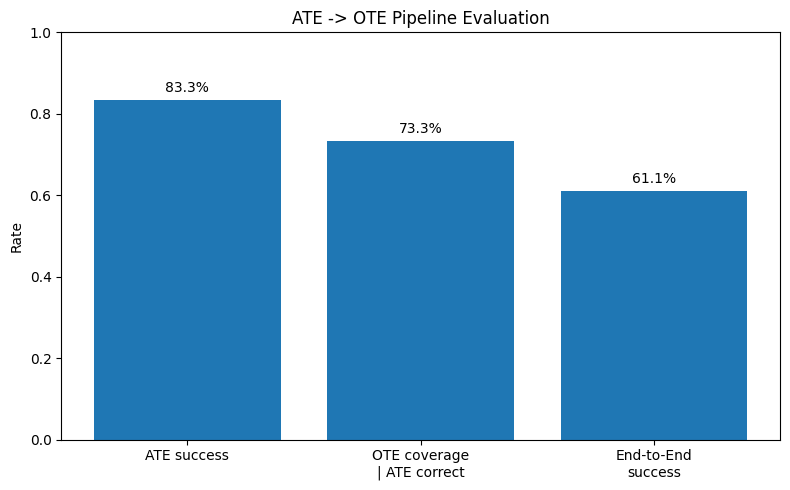

In [84]:
# Graph

labels = [
    "ATE success",
    "OTE coverage\n| ATE correct",
    "End-to-End\nsuccess"
]
values = [
    ate_success,
    ote_coverage,
    eval_success
]
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)
plt.ylim(0, 1)
plt.ylabel("Rate")
plt.title("ATE -> OTE Pipeline Evaluation")
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.1%}",
        ha="center"
    )
plt.tight_layout()
plt.show()

Sentiment

In [85]:
# Sentiment evaluation

sentiment_gold = gold_eval.copy()
sentiment_gold["sentence_norm"] = (
    sentiment_gold["sentence"]
    .apply(normalize_text)
)
sentiment_gold["aspect_norm"] = (
    sentiment_gold["aspectTerm"]
    .apply(normalize_text)
)
sentiment_pred = pred_df.copy()
sentiment_pred["sentence_norm"] = (
    sentiment_pred["sentence"]
    .apply(normalize_text)
)
sentiment_pred["aspect_norm"] = (
    sentiment_pred["aspect_term"]
    .apply(normalize_text)
)
print("Gold sentiment annotations:", len(sentiment_gold))
print("Predicted test set instances:", len(sentiment_pred))

Gold sentiment annotations: 18
Predicted test set instances: 791


In [86]:
sentiment_rows = []
for _, gold in sentiment_gold.iterrows():
    sentence = gold["sentence"]
    aspect = gold["aspectTerm"]
    gold_sentiment = gold["polarity"]
    sentence_norm = normalize_text(sentence)
    aspect_norm = normalize_text(aspect)
    candidates = sentiment_pred[
        (sentiment_pred["sentence_norm"] == sentence_norm) &
        (sentiment_pred["aspect_norm"] == aspect_norm)
    ]
    if len(candidates) == 0:
        sentiment_rows.append({
            "sentence": sentence,
            "aspect": aspect,
            "gold_sentiment": gold_sentiment,
            "predicted_sentiment": None,
            "ate_correct": False
        })
        continue
    pred = candidates.iloc[0]
    predicted_sentiment = pred["sentiment"]
    sentiment_rows.append({
        "sentence": sentence,
        "aspect": aspect,
        "gold_sentiment": gold_sentiment,
        "predicted_sentiment": predicted_sentiment,
        "ate_correct": True
    })
sentiment_results = pd.DataFrame(sentiment_rows)
sentiment_results.head(20)

,sentence,aspect,gold_sentiment,predicted_sentiment,ate_correct
0,"Found service above average, but that could be...",service,positive,None,True
1,The best pad thai i've ever had.,pad thai,positive,positive,True
2,A narrow corridor leads to a tiny space where ...,counter,negative,None,False
3,"The Halibut was too salty, dessert was so so (...",service,negative,negative,True
4,"The menu looked good, except for offering the ...",menu,positive,positive,True
5,"try the spicy shrimp appetizer (again, not the...",lamb vindaloo,positive,positive,True
6,"The service is excellent, the decor is great, ...",service,positive,positive,True
7,"Although the tables may be closely situated, t...",candle-light,positive,None,False
8,"Delicious food, excellent service, and a prett...",food,positive,positive,True
9,"The Halibut was too salty, dessert was so so (...",Halibut,negative,neutral,True


In [87]:
sentiment_ate_correct = sentiment_results[
    sentiment_results["ate_correct"]
].copy()
print(
    "Correctly detected aspects:",
    len(sentiment_ate_correct),
    "/",
    len(sentiment_results)
)
sentiment_valid = sentiment_ate_correct[
    sentiment_ate_correct["predicted_sentiment"].notna()
].copy()
print(
    "Valid sentiment predictions:",
    len(sentiment_valid),
    "/",
    len(sentiment_ate_correct)
)
y_true = sentiment_valid["gold_sentiment"]
y_pred = sentiment_valid["predicted_sentiment"]
sentiment_accuracy = accuracy_score(
    y_true,
    y_pred
)
present_labels = sorted(y_true.unique())
print("Classes present in gold:", present_labels)
precision_macro, recall_macro, f1_macro, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=present_labels,
        average="macro",
        zero_division=0
    )
)
print("\nSentiment Evaluation:")
print(f"Accuracy:          {sentiment_accuracy:.4f}")
print(f"Macro Precision:   {precision_macro:.4f}")
print(f"Macro Recall:      {recall_macro:.4f}")
print(f"Macro F1:          {f1_macro:.4f}")

Correctly detected aspects: 15 / 18
Valid sentiment predictions: 13 / 15
Classes present in gold: ['negative', 'neutral', 'positive']

Sentiment Evaluation:
Accuracy:          0.8462
Macro Precision:   0.8000
Macro Recall:      0.7778
Macro F1:          0.7047


In [88]:
# Classification report

print(
    classification_report(
        y_true,
        y_pred,
        labels=["positive", "negative", "neutral"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    positive       0.90      1.00      0.95         9
    negative       1.00      0.33      0.50         3
     neutral       0.50      1.00      0.67         1

    accuracy                           0.85        13
   macro avg       0.80      0.78      0.70        13
weighted avg       0.89      0.85      0.82        13



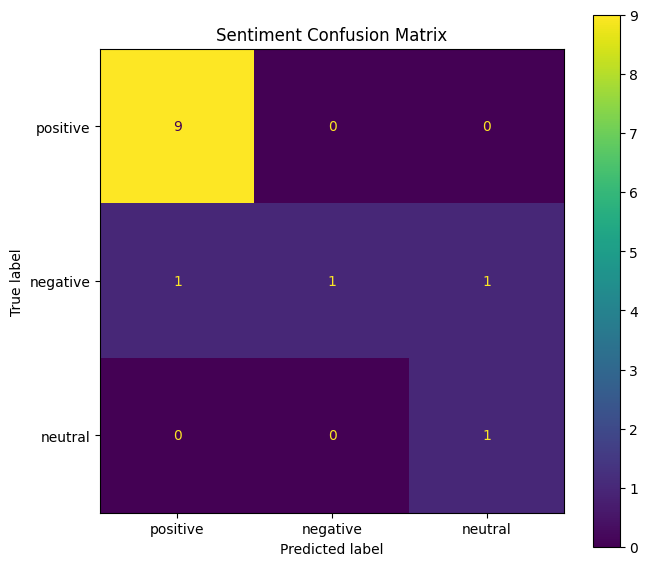

In [89]:
# Confusion matrix

labels = ["positive", "negative", "neutral"]
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)
cm_df = pd.DataFrame(
    cm,
    index=[f"True {label}" for label in labels],
    columns=[f"Pred {label}" for label in labels]
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(
    ax=ax,
    values_format="d"
)
plt.title("Sentiment Confusion Matrix")
plt.tight_layout()
plt.show()

In [90]:
# Sentiment coverage

sentiment_coverage = (
    len(sentiment_valid) /
    len(sentiment_ate_correct)
    if len(sentiment_ate_correct) > 0
    else 0
)
print(
    f"Sentiment coverage given correct ATE: "
    f"{sentiment_coverage:.4f} "
    f"({sentiment_coverage * 100:.2f}%)"
)

Sentiment coverage given correct ATE: 0.8667 (86.67%)


In [91]:
# Final result table

final_pipeline_metrics = pd.DataFrame({

    "Stage": [
        "ATE",
        "ATE -> OTE",
        "ATE -> OTE",
        "ATE -> OTE Pair",
        "Sentiment",
        "Sentiment"
    ],
    "Metric": [
        "Success Rate",
        "Opinion Coverage",
        "End-to-End Coverage",
        "F1",
        "Coverage | ATE correct",
        "Macro F1"
    ],
    "Score": [
        ate_success,
        ote_coverage,
        eval_success,
        f1,
        sentiment_coverage,
        f1_macro
    ]
})
final_pipeline_metrics

,Stage,Metric,Score
0,ATE,Success Rate,0.833333
1,ATE -> OTE,Opinion Coverage,0.733333
2,ATE -> OTE,End-to-End Coverage,0.611111
3,ATE -> OTE Pair,F1,0.511628
4,Sentiment,Coverage | ATE correct,0.866667
5,Sentiment,Macro F1,0.704678


In [92]:
# Sentiment result table

sentiment_metrics = pd.DataFrame({

    "Metric": [
        "Coverage | ATE correct",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],

    "Score": [
        sentiment_coverage,
        sentiment_accuracy,
        precision_macro,
        recall_macro,
        f1_macro
    ]
})

sentiment_metrics

,Metric,Score
0,Coverage | ATE correct,0.866667
1,Accuracy,0.846154
2,Macro Precision,0.800000
3,Macro Recall,0.777778
4,Macro F1,0.704678


In [93]:
# Error analysis

sentiment_errors = sentiment_valid[
    sentiment_valid["gold_sentiment"] !=
    sentiment_valid["predicted_sentiment"]
].copy()

print("Sentiment errors:", len(sentiment_errors))
print()

for _, row in sentiment_errors.iterrows():

    print("Sentence:")
    print(row["sentence"])

    print(f"Aspect:       {row['aspect']}")
    print(f"Gold:         {row['gold_sentiment']}")
    print(f"Predicted:    {row['predicted_sentiment']}")
    print("-" * 80)

Sentiment errors: 2

Sentence:
The Halibut was too salty, dessert was so so (don't waste any of your calories) and service was poor.
Aspect:       Halibut
Gold:         negative
Predicted:    neutral
--------------------------------------------------------------------------------
Sentence:
The Halibut was too salty, dessert was so so (don't waste any of your calories) and service was poor.
Aspect:       dessert
Gold:         negative
Predicted:    positive
--------------------------------------------------------------------------------


In [94]:
# Error analysis

for _, row in sentiment_errors.iterrows():
    sentence = row["sentence"]
    aspect = row["aspect"]
    candidates = sentiment_pred[
        (sentiment_pred["sentence_norm"] == normalize_text(sentence)) &
        (sentiment_pred["aspect_norm"] == normalize_text(aspect))
    ]
    print("=" * 100)
    print(f"ASPECT: {aspect}")
    print(f"GOLD SENTIMENT: {row['gold_sentiment']}")
    print(f"PREDICTED SENTIMENT: {row['predicted_sentiment']}")
    print()
    print(f"SENTENCE:\n{sentence}")
    print()
    if len(candidates) > 0:
        pred = candidates.iloc[0]
        print("Opinion terms:")
        print(pred.get("opinion_terms", []))
        print()
        print("Opinion sentiments:")
        print(pred.get("opinion_sentiments", []))
        print()
        print("Opinion scores:")
        print(pred.get("opinion_scores", []))
    else:
        print("No matching prediction found.")
    print()

ASPECT: Halibut
GOLD SENTIMENT: negative
PREDICTED SENTIMENT: neutral

SENTENCE:
The Halibut was too salty, dessert was so so (don't waste any of your calories) and service was poor.

Opinion terms:
['too salty']

Opinion sentiments:
['neutral']

Opinion scores:
[0.0]

ASPECT: dessert
GOLD SENTIMENT: negative
PREDICTED SENTIMENT: positive

SENTENCE:
The Halibut was too salty, dessert was so so (don't waste any of your calories) and service was poor.

Opinion terms:
["n't waste poor"]

Opinion sentiments:
['positive']

Opinion scores:
[0.5975]



# Evaluation - Laptop dataset

In [95]:
GOLD_LAPTOP = "/content/drive/MyDrive/SII/gold_standard_laptops.csv"
gold_laptop = pd.read_csv(GOLD_LAPTOP)
print("Laptop gold annotations:", len(gold_laptop))
print("Unique sentences:", gold_laptop["sentence"].nunique())
gold_laptop.head()

Laptop gold annotations: 276
Unique sentences: 243


,sentence,aspectTerm,opinionPhrase,polarity
0,"With awesome graphics and assuring security, i...",graphics,awesome,positive
1,I would recommend this laptop to anyone lookin...,quality,great,positive
2,The built-in webcam is great for Skype and sim...,built-in webcam,great,positive
3,"Crisp screen, great battery life, and plenty o...",battery life,great,positive
4,"I love this program, it is superior to windows...",program,love,positive


In [96]:
# Dataset information

print("Columns:")
print(gold_laptop.columns.tolist())
print("\nMissing values:")
print(gold_laptop.isna().sum())
print("\nPolarity distribution:")
print(gold_laptop["polarity"].value_counts())

Columns:
['sentence', 'aspectTerm', 'opinionPhrase', 'polarity']

Missing values:
sentence         0
aspectTerm       0
opinionPhrase    0
polarity         0
dtype: int64

Polarity distribution:
polarity
positive    218
negative     58
Name: count, dtype: int64


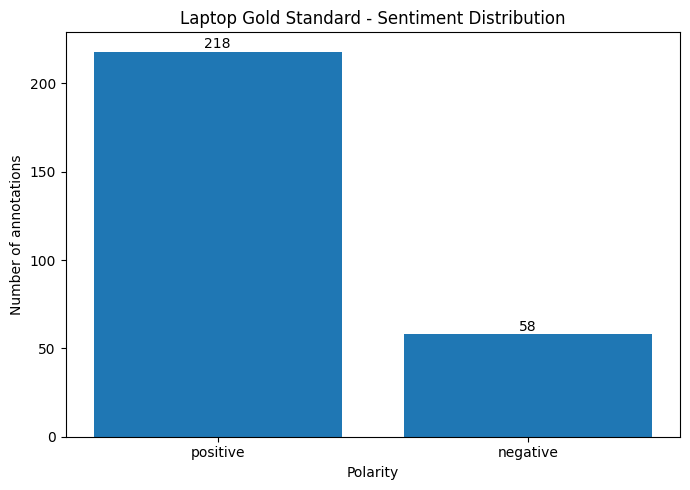

In [97]:
# Polarity distribution

polarity_distribution = (
    gold_laptop["polarity"]
    .value_counts()
)
plt.figure(figsize=(7, 5))
bars = plt.bar(
    polarity_distribution.index,
    polarity_distribution.values
)
plt.ylabel("Number of annotations")
plt.xlabel("Polarity")
plt.title("Laptop Gold Standard - Sentiment Distribution")
for bar, value in zip(
    bars,
    polarity_distribution.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        str(value),
        ha="center"
    )
plt.tight_layout()
plt.show()

In [98]:
laptop_sentences = (
    gold_laptop["sentence"]
    .dropna()
    .drop_duplicates()
    .tolist()
)
print("Laptop annotations:", len(gold_laptop))
print("Unique laptop sentences:", len(laptop_sentences))

Laptop annotations: 276
Unique laptop sentences: 243


In [99]:
# ATE

laptop_results = []
for sentence in tqdm(
    laptop_sentences,
    desc="Laptop ATE"
):
    tokens, spans, labels = predict_labels(sentence)
    aspects = extract_aspects(
        tokens,
        spans,
        labels
    )
    for aspect in aspects:
        laptop_results.append({
            "sentence": sentence,
            "aspect_term": aspect["aspect_term"],
            "token_start": aspect["token_start"],
            "token_end": aspect["token_end"],
            "char_start": aspect["char_start"],
            "char_end": aspect["char_end"]
        })
laptop_df = pd.DataFrame(laptop_results)
print(
    "Predicted laptop aspect instances:",
    len(laptop_df)
)
laptop_df.head(20)

Laptop ATE: 100%|██████████| 243/243 [00:00<00:00, 711.29it/s]

Predicted laptop aspect instances: 172


,sentence,aspect_term,token_start,token_end,char_start,char_end
0,"With awesome graphics and assuring security, i...",graphics,2,2,13,21
1,I would recommend this laptop to anyone lookin...,quality,25,25,125,132
2,The built-in webcam is great for Skype and sim...,built-in webcam,1,2,4,19
3,While Apple's saving grace is the fact that th...,premium,36,36,184,191
4,"I love the solid machined aluminum frame, and ...",machined aluminum frame,4,6,17,40
5,I like how the Mac OS is so simple and easy to...,Mac OS,4,5,15,21
6,/ awesome cooling system/ much better grafics ...,grafics card,6,7,38,50
7,/ awesome cooling system/ much better grafics ...,ATI 5870 ) / 8GB RAM/ LED backlit screen ...,9,18,52,94
8,This laptop meets every expectation and Window...,laptop meets,1,2,5,17
9,Now for the hardware problems.,hardware problems,3,4,12,29


In [100]:
print(
    "Sentences with at least one predicted aspect:",
    laptop_df["sentence"].nunique()
)
print(
    "Total unique sentences:",
    len(laptop_sentences)
)
print(
    "Average predicted aspects per sentence:",
    len(laptop_df) / len(laptop_sentences)
)

Sentences with at least one predicted aspect: 139
Total unique sentences: 243
Average predicted aspects per sentence: 0.7078189300411523


In [101]:
# OTE

laptop_df["opinion_terms"] = laptop_df.apply(
    lambda row: extract_opinion_dependency(
        row["sentence"],
        row["aspect_term"]
    ),
    axis=1
)
laptop_df[
    [
        "sentence",
        "aspect_term",
        "opinion_terms"
    ]
].head(20)

,sentence,aspect_term,opinion_terms
0,"With awesome graphics and assuring security, i...",graphics,"[awesome, assuring]"
1,I would recommend this laptop to anyone lookin...,quality,[great]
2,The built-in webcam is great for Skype and sim...,built-in webcam,[great]
3,While Apple's saving grace is the fact that th...,premium,[]
4,"I love the solid machined aluminum frame, and ...",machined aluminum frame,"[solid, love solid machined]"
5,I like how the Mac OS is so simple and easy to...,Mac OS,[so simple]
6,/ awesome cooling system/ much better grafics ...,grafics card,"[much better, awesome]"
7,/ awesome cooling system/ much better grafics ...,ATI 5870 ) / 8GB RAM/ LED backlit screen ...,"[much better, awesome]"
8,This laptop meets every expectation and Window...,laptop meets,[]
9,Now for the hardware problems.,hardware problems,[Now]


In [102]:
# Sentiment

laptop_sentiment_results = laptop_df.apply(
    lambda row: aspect_sentiment(
        row["aspect_term"],
        row["opinion_terms"]
    ),
    axis=1
)
laptop_df["sentiment"] = (
    laptop_sentiment_results.apply(
        lambda x: x[0]
    )
)
laptop_df["opinion_sentiments"] = (
    laptop_sentiment_results.apply(
        lambda x: x[1]
    )
)
laptop_df["opinion_scores"] = (
    laptop_sentiment_results.apply(
        lambda x: x[2]
    )
)

In [103]:
laptop_df[
    [
        "sentence",
        "aspect_term",
        "opinion_terms",
        "opinion_sentiments",
        "sentiment",
        "opinion_scores"
    ]
].head(30)

,sentence,aspect_term,opinion_terms,opinion_sentiments,sentiment,opinion_scores
0,"With awesome graphics and assuring security, i...",graphics,"[awesome, assuring]","[positive, positive]",positive,"[0.6249, 0.3818]"
1,I would recommend this laptop to anyone lookin...,quality,[great],[positive],positive,[0.6249]
2,The built-in webcam is great for Skype and sim...,built-in webcam,[great],[positive],positive,[0.6249]
3,While Apple's saving grace is the fact that th...,premium,[],None,None,None
4,"I love the solid machined aluminum frame, and ...",machined aluminum frame,"[solid, love solid machined]","[positive, positive]",positive,"[0.1531, 0.7003]"
5,I like how the Mac OS is so simple and easy to...,Mac OS,[so simple],[neutral],neutral,[0.0]
6,/ awesome cooling system/ much better grafics ...,grafics card,"[much better, awesome]","[positive, positive]",positive,"[0.4404, 0.6249]"
7,/ awesome cooling system/ much better grafics ...,ATI 5870 ) / 8GB RAM/ LED backlit screen ...,"[much better, awesome]","[positive, positive]",positive,"[0.4404, 0.6249]"
8,This laptop meets every expectation and Window...,laptop meets,[],None,None,None
9,Now for the hardware problems.,hardware problems,[Now],[neutral],neutral,[0.0]


In [104]:
gold_laptop_eval = gold_laptop.copy()
gold_laptop_eval["sentence_norm"] = (
    gold_laptop_eval["sentence"]
    .apply(normalize_text)
)
gold_laptop_eval["aspect_norm"] = (
    gold_laptop_eval["aspectTerm"]
    .apply(normalize_text)
)
laptop_pred = laptop_df.copy()
laptop_pred["sentence_norm"] = (
    laptop_pred["sentence"]
    .apply(normalize_text)
)
laptop_pred["aspect_norm"] = (
    laptop_pred["aspect_term"]
    .apply(normalize_text)
)
print(
    "Gold laptop annotations:",
    len(gold_laptop_eval)
)
print(
    "Predicted laptop aspects:",
    len(laptop_pred)
)

Gold laptop annotations: 276
Predicted laptop aspects: 172


In [105]:
def find_laptop_predicted_aspect(sentence, aspect):
    sentence_norm = normalize_text(sentence)
    aspect_norm = normalize_text(aspect)
    candidates = laptop_pred[
        (laptop_pred["sentence_norm"]== sentence_norm)&(laptop_pred["aspect_norm"]== aspect_norm)
    ]
    return candidates

In [106]:
# ATE/OTE

laptop_evaluation_rows = []
for _, gold in gold_laptop_eval.iterrows():
    sentence = gold["sentence"]
    gold_aspect = gold["aspectTerm"]
    gold_opinions = split_gold_opinions(
        gold["opinionPhrase"]
    )
    candidates = find_laptop_predicted_aspect(
        sentence,
        gold_aspect
    )
    if len(candidates) == 0:
        laptop_evaluation_rows.append({
            "sentence": sentence,
            "gold_aspect": gold_aspect,
            "predicted_aspect": None,
            "gold_opinions": gold_opinions,
            "predicted_opinions": [],
            "ate_correct": False,
            "ote_correct": False,
            "eval_correct": False
        })
        continue
    pred = candidates.iloc[0]
    predicted_opinions = [
        normalize_text(op)
        for op in pred["opinion_terms"]
    ]
    opinion_matches = []
    for gold_opinion in gold_opinions:
        match = any(
            gold_opinion == pred_opinion
            for pred_opinion
            in predicted_opinions
        )
        opinion_matches.append(match)
    ate_correct = True
    ote_correct = any(
        opinion_matches
    )
    eval_correct = (
        ate_correct
        and len(gold_opinions) > 0
        and all(opinion_matches)
    )
    laptop_evaluation_rows.append({
        "sentence": sentence,
        "gold_aspect": gold_aspect,
        "predicted_aspect":
            pred["aspect_term"],
        "gold_opinions":
            gold_opinions,
        "predicted_opinions":
            predicted_opinions,
        "ate_correct":
            ate_correct,
        "ote_correct":
            ote_correct,
        "eval_correct":
            eval_correct
    })

In [107]:
laptop_eval_results = pd.DataFrame(
    laptop_evaluation_rows
)
print(
    "Laptop evaluation instances:",
    len(laptop_eval_results)
)
laptop_eval_results.head(20)

Laptop evaluation instances: 276


,sentence,gold_aspect,predicted_aspect,gold_opinions,predicted_opinions,ate_correct,ote_correct,eval_correct
0,"With awesome graphics and assuring security, i...",graphics,graphics,[awesome],"[awesome, assuring]",True,True,True
1,I would recommend this laptop to anyone lookin...,quality,quality,[great],[great],True,True,True
2,The built-in webcam is great for Skype and sim...,built-in webcam,built-in webcam,[great],[great],True,True,True
3,"Crisp screen, great battery life, and plenty o...",battery life,None,[great],[],False,False,False
4,"I love this program, it is superior to windows...",program,None,[love],[],False,False,False
5,"The cover for the DVD drive soon came off, too...",construction quality,None,[poor],[],False,False,False
6,While Apple's saving grace is the fact that th...,support,None,[great],[],False,False,False
7,"I love the solid machined aluminum frame, and ...",machined aluminum frame,machined aluminum frame,[love],"[solid, love solid machined]",True,False,False
8,The display is beyond horrible.,display,None,[horrible],[],False,False,False
9,I like how the Mac OS is so simple and easy to...,Mac OS,Mac OS,[like],[so simple],True,False,False


In [108]:
# ATE success

laptop_ate_success = (
    laptop_eval_results[
        "ate_correct"
    ].mean()
)
print(
    f"Laptop ATE success: "
    f"{laptop_ate_success:.4f} "
    f"({laptop_ate_success * 100:.2f}%)"
)

Laptop ATE success: 0.3261 (32.61%)


In [109]:
# OTE coverage

laptop_ate_correct_df = (
    laptop_eval_results[
        laptop_eval_results[
            "ate_correct"
        ]
    ].copy()
)
laptop_ote_coverage = (
    laptop_ate_correct_df[
        "ote_correct"
    ].mean()
    if len(
        laptop_ate_correct_df
    ) > 0
    else 0
)
print(
    f"Laptop OTE coverage given correct ATE: "
    f"{laptop_ote_coverage:.4f} "
    f"({laptop_ote_coverage * 100:.2f}%)"
)

Laptop OTE coverage given correct ATE: 0.6556 (65.56%)


In [110]:
# Final ATE/OTE

laptop_eval_success = (
    laptop_eval_results[
        "eval_correct"
    ].mean()
)
print(
    f"Laptop ATE -> OTE success: "
    f"{laptop_eval_success:.4f} "
    f"({laptop_eval_success * 100:.2f}%)"
)

Laptop ATE -> OTE success: 0.2138 (21.38%)


In [111]:
# Gold/Predicted pairs

laptop_gold_pairs = set()
for _, row in gold_laptop_eval.iterrows():
    sentence = normalize_text(
        row["sentence"]
    )
    aspect = normalize_text(
        row["aspectTerm"]
    )
    for opinion in split_gold_opinions(
        row["opinionPhrase"]
    ):
        laptop_gold_pairs.add(
            (
                sentence,
                aspect,
                opinion
            )
        )

In [112]:
# Predicted pairs

laptop_gold_sentences_set = set(
    gold_laptop_eval[
        "sentence"
    ].map(normalize_text)
)
laptop_pred_pairs = set()
for _, row in laptop_pred.iterrows():
    sentence = normalize_text(
        row["sentence"]
    )
    if sentence not in laptop_gold_sentences_set:
        continue
    aspect = normalize_text(
        row["aspect_term"]
    )
    for opinion in row["opinion_terms"]:
        opinion_norm = normalize_text(
            opinion
        )
        if opinion_norm:
            laptop_pred_pairs.add(
                (
                    sentence,
                    aspect,
                    opinion_norm
                )
            )
print(
    "Laptop gold pairs:",
    len(laptop_gold_pairs)
)
print(
    "Laptop predicted pairs:",
    len(laptop_pred_pairs)
)

Laptop gold pairs: 276
Laptop predicted pairs: 141


In [113]:
# ATE/OTE metrics

laptop_TP = len(laptop_gold_pairs&laptop_pred_pairs)
laptop_FP = len(laptop_pred_pairs - laptop_gold_pairs)
laptop_FN = len(laptop_gold_pairs - laptop_pred_pairs)
laptop_pair_precision = (laptop_TP/(laptop_TP + laptop_FP)) if (laptop_TP + laptop_FP) > 0 else 0
laptop_pair_recall = (laptop_TP/(laptop_TP + laptop_FN)) if (laptop_TP + laptop_FN) > 0 else 0
laptop_pair_f1 = (2*laptop_pair_precision*laptop_pair_recall)/(laptop_pair_precision + laptop_pair_recall) if (laptop_pair_precision + laptop_pair_recall) > 0 else 0
print(
    "Laptop Aspect–Opinion Pair Evaluation:"
)
print(f"TP:        {laptop_TP}")
print(f"FP:        {laptop_FP}")
print(f"FN:        {laptop_FN}")
print(
    f"Precision: "
    f"{laptop_pair_precision:.4f}"
)
print(
    f"Recall:    "
    f"{laptop_pair_recall:.4f}"
)
print(
    f"F1:        "
    f"{laptop_pair_f1:.4f}"
)

Laptop Aspect–Opinion Pair Evaluation:
TP:        59
FP:        82
FN:        217
Precision: 0.4184
Recall:    0.2138
F1:        0.2830


In [114]:
# Error analysis

def classify_laptop_error(row):
    if row["eval_correct"]:
        return "Complete success"
    if not row["ate_correct"]:
        return "ATE failure"
    if not row["ote_correct"]:
        return "OTE failure"
    return "Partial / incomplete OTE match"
laptop_eval_results[
    "error_type"
] = laptop_eval_results.apply(
    classify_laptop_error,
    axis=1
)

In [115]:
laptop_error_distribution = (
    laptop_eval_results[
        "error_type"
    ].value_counts()
)
print(
    laptop_error_distribution
)

error_type
ATE failure         186
Complete success     59
OTE failure          31
Name: count, dtype: int64


In [116]:
laptop_error_distribution_pct = (
    laptop_eval_results[
        "error_type"
    ]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)
laptop_error_distribution_pct

,proportion
error_type,
ATE failure,67.39
Complete success,21.38
OTE failure,11.23


In [117]:
laptop_error_analysis = (
    laptop_eval_results[
        ~laptop_eval_results[
            "eval_correct"
        ]
    ].copy()
)
print(
    "Failed laptop examples:",
    len(laptop_error_analysis)
)
laptop_error_analysis[
    [
        "sentence",
        "gold_aspect",
        "predicted_aspect",
        "gold_opinions",
        "predicted_opinions",
        "ate_correct",
        "ote_correct",
        "error_type"
    ]
].head(30)

Failed laptop examples: 217


,sentence,gold_aspect,predicted_aspect,gold_opinions,predicted_opinions,ate_correct,ote_correct,error_type
3,"Crisp screen, great battery life, and plenty o...",battery life,None,[great],[],False,False,ATE failure
4,"I love this program, it is superior to windows...",program,None,[love],[],False,False,ATE failure
5,"The cover for the DVD drive soon came off, too...",construction quality,None,[poor],[],False,False,ATE failure
6,While Apple's saving grace is the fact that th...,support,None,[great],[],False,False,ATE failure
7,"I love the solid machined aluminum frame, and ...",machined aluminum frame,machined aluminum frame,[love],"[solid, love solid machined]",True,False,OTE failure
8,The display is beyond horrible.,display,None,[horrible],[],False,False,ATE failure
9,I like how the Mac OS is so simple and easy to...,Mac OS,Mac OS,[like],[so simple],True,False,OTE failure
10,/ awesome cooling system/ much better grafics ...,grafics card,grafics card,[better],"[much better, awesome]",True,False,OTE failure
11,This laptop meets every expectation and Window...,Windows 7,None,[great],[],False,False,ATE failure
12,Summary: HP knew they were shipping out bad BI...,BIOS,None,[bad],[],False,False,ATE failure


In [118]:
# Sentiment evaluation

sentiment_gold_laptop = (
    gold_laptop_eval.copy()
)
sentiment_pred_laptop = (
    laptop_pred.copy()
)
print(
    "Laptop gold sentiment annotations:",
    len(sentiment_gold_laptop)
)
print(
    "Laptop predicted aspect instances:",
    len(sentiment_pred_laptop)
)

Laptop gold sentiment annotations: 276
Laptop predicted aspect instances: 172


In [119]:
laptop_sentiment_rows = []
for _, gold in sentiment_gold_laptop.iterrows():
    sentence = gold["sentence"]
    aspect = gold["aspectTerm"]
    gold_sentiment = gold["polarity"]
    sentence_norm = normalize_text(
        sentence
    )
    aspect_norm = normalize_text(
        aspect
    )
    candidates = sentiment_pred_laptop[(sentiment_pred_laptop["sentence_norm"] == sentence_norm) & (sentiment_pred_laptop["aspect_norm"] == aspect_norm)]
    if len(candidates) == 0:
        laptop_sentiment_rows.append({
            "sentence":
                sentence,
            "aspect":
                aspect,
            "gold_sentiment":
                gold_sentiment,
            "predicted_sentiment":
                None,
            "ate_correct":
                False
        })
        continue
    pred = candidates.iloc[0]
    predicted_sentiment = (
        pred["sentiment"]
    )
    laptop_sentiment_rows.append({
        "sentence":
            sentence,
        "aspect":
            aspect,
        "gold_sentiment":
            gold_sentiment,
        "predicted_sentiment":
            predicted_sentiment,
        "ate_correct":
            True
    })
laptop_sentiment_eval = pd.DataFrame(
    laptop_sentiment_rows
)
laptop_sentiment_eval.head(20)

,sentence,aspect,gold_sentiment,predicted_sentiment,ate_correct
0,"With awesome graphics and assuring security, i...",graphics,positive,positive,True
1,I would recommend this laptop to anyone lookin...,quality,positive,positive,True
2,The built-in webcam is great for Skype and sim...,built-in webcam,positive,positive,True
3,"Crisp screen, great battery life, and plenty o...",battery life,positive,None,False
4,"I love this program, it is superior to windows...",program,positive,None,False
5,"The cover for the DVD drive soon came off, too...",construction quality,negative,None,False
6,While Apple's saving grace is the fact that th...,support,positive,None,False
7,"I love the solid machined aluminum frame, and ...",machined aluminum frame,positive,positive,True
8,The display is beyond horrible.,display,negative,None,False
9,I like how the Mac OS is so simple and easy to...,Mac OS,positive,neutral,True


In [120]:
# Sentiment coverage

laptop_sentiment_ate_correct = (
    laptop_sentiment_eval[
        laptop_sentiment_eval[
            "ate_correct"
        ]
    ].copy()
)
laptop_sentiment_valid = (
    laptop_sentiment_ate_correct[
        laptop_sentiment_ate_correct[
            "predicted_sentiment"
        ].notna()
    ].copy()
)
print(
    "Correctly detected laptop aspects:",
    len(laptop_sentiment_ate_correct),
    "/",
    len(laptop_sentiment_eval)
)
print(
    "Valid laptop sentiment predictions:",
    len(laptop_sentiment_valid),
    "/",
    len(laptop_sentiment_ate_correct)
)
laptop_sentiment_coverage = (
    len(laptop_sentiment_valid)
    /
    len(laptop_sentiment_ate_correct)
    if len(
        laptop_sentiment_ate_correct
    ) > 0
    else 0
)
print(
    f"\nLaptop sentiment coverage "
    f"given correct ATE: "
    f"{laptop_sentiment_coverage:.4f} "
    f"({laptop_sentiment_coverage * 100:.2f}%)"
)

Correctly detected laptop aspects: 90 / 276
Valid laptop sentiment predictions: 75 / 90

Laptop sentiment coverage given correct ATE: 0.8333 (83.33%)


In [121]:
# Sentiment metrics

y_true_laptop = (
    laptop_sentiment_valid[
        "gold_sentiment"
    ]
)
y_pred_laptop = (
    laptop_sentiment_valid[
        "predicted_sentiment"
    ]
)
laptop_sentiment_accuracy = (
    accuracy_score(
        y_true_laptop,
        y_pred_laptop
    )
)
laptop_present_labels = sorted(
    y_true_laptop.unique()
)
print(
    "Classes present in laptop gold:",
    laptop_present_labels
)
(
    laptop_precision_macro,
    laptop_recall_macro,
    laptop_f1_macro,
    _
) = precision_recall_fscore_support(
    y_true_laptop,
    y_pred_laptop,
    labels=laptop_present_labels,
    average="macro",
    zero_division=0
)
print(
    "\nLaptop Sentiment Evaluation"
)
print(
    f"Accuracy:          "
    f"{laptop_sentiment_accuracy:.4f}"
)
print(
    f"Macro Precision:   "
    f"{laptop_precision_macro:.4f}"
)
print(
    f"Macro Recall:      "
    f"{laptop_recall_macro:.4f}"
)
print(
    f"Macro F1:          "
    f"{laptop_f1_macro:.4f}"
)

Classes present in laptop gold: ['negative', 'positive']

Laptop Sentiment Evaluation
Accuracy:          0.8800
Macro Precision:   0.9167
Macro Recall:      0.7399
Macro F1:          0.8136


In [122]:
# Classification report

print(
    classification_report(
        y_true_laptop,
        y_pred_laptop,
        labels=laptop_present_labels,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative       0.83      0.56      0.67         9
    positive       1.00      0.92      0.96        66

   micro avg       0.99      0.88      0.93        75
   macro avg       0.92      0.74      0.81        75
weighted avg       0.98      0.88      0.93        75



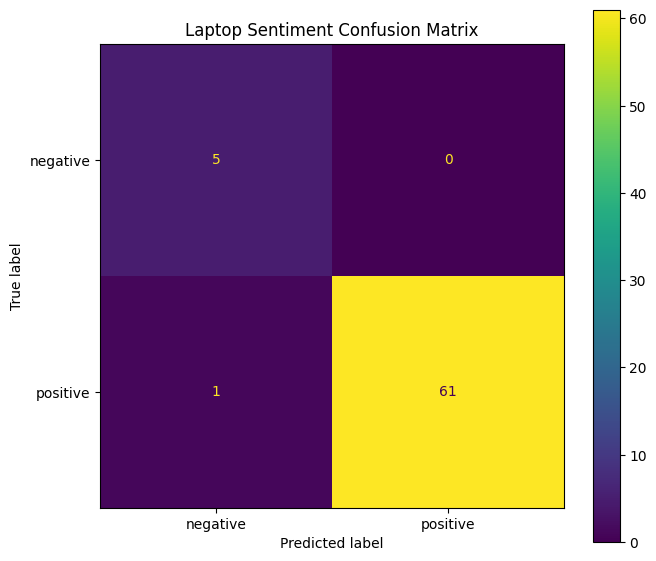

In [123]:
# Confusion matrix

laptop_cm = confusion_matrix(
    y_true_laptop,
    y_pred_laptop,
    labels=laptop_present_labels
)
laptop_cm_df = pd.DataFrame(
    laptop_cm,
    index=[
        f"True {label}"
        for label
        in laptop_present_labels
    ],
    columns=[
        f"Pred {label}"
        for label
        in laptop_present_labels
    ]
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=laptop_cm,
    display_labels=laptop_present_labels
)
fig, ax = plt.subplots(
    figsize=(7, 6)
)
disp.plot(
    ax=ax,
    values_format="d"
)
plt.title(
    "Laptop Sentiment Confusion Matrix"
)
plt.tight_layout()
plt.show()

In [124]:
# Sentiment results table

laptop_sentiment_metrics = pd.DataFrame({
    "Metric": [
        "Coverage | ATE correct",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Score": [
        laptop_sentiment_coverage,
        laptop_sentiment_accuracy,
        laptop_precision_macro,
        laptop_recall_macro,
        laptop_f1_macro
    ]
})
laptop_sentiment_metrics

,Metric,Score
0,Coverage | ATE correct,0.833333
1,Accuracy,0.880000
2,Macro Precision,0.916667
3,Macro Recall,0.739899
4,Macro F1,0.813648


In [125]:
# Sentiment error analysis

laptop_sentiment_errors = (
    laptop_sentiment_valid[
        laptop_sentiment_valid[
            "gold_sentiment"
        ]
        !=
        laptop_sentiment_valid[
            "predicted_sentiment"
        ]
    ].copy()
)
print(
    "Laptop sentiment errors:",
    len(laptop_sentiment_errors)
)
laptop_sentiment_errors[
    [
        "sentence",
        "aspect",
        "gold_sentiment",
        "predicted_sentiment"
    ]
].head(30)

Laptop sentiment errors: 9


,sentence,aspect,gold_sentiment,predicted_sentiment
9,I like how the Mac OS is so simple and easy to...,Mac OS,positive,neutral
33,"However, I love this particular Mac because it...",mouse pad,positive,neutral
36,since then i have had minor problems with sl...,operation,negative,neutral
55,The processor is very quick and effective as I...,processor,positive,neutral
97,in May I started having problems with the USB ...,USB ports,negative,neutral
111,"Who couldn't love a DVD burner, 80-gigabyte HD...",DVD burner,positive,negative
155,After having two PC laptops die with in the pa...,design,positive,neutral
193,Enabling the battery timer is useless.,battery timer,negative,neutral
261,After way too many times sending the thing in ...,delivery service,negative,neutral


In [126]:
for _, row in (
    laptop_sentiment_errors
    .head(30)
    .iterrows()
):
    sentence = row["sentence"]
    aspect = row["aspect"]
    candidates = sentiment_pred_laptop[(sentiment_pred_laptop["sentence_norm"] == normalize_text(sentence)) & (sentiment_pred_laptop["aspect_norm"] == normalize_text(aspect))]
    print("=" * 100)
    print(
        f"ASPECT: {aspect}"
    )
    print(
        f"GOLD SENTIMENT: "
        f"{row['gold_sentiment']}"
    )
    print(
        f"PREDICTED SENTIMENT: "
        f"{row['predicted_sentiment']}"
    )
    print()

    print(
        f"SENTENCE:\n{sentence}"
    )
    print()
    if len(candidates) > 0:
        pred = candidates.iloc[0]
        print("Opinion terms:")
        print(
            pred.get(
                "opinion_terms",
                []
            )
        )
        print()
        print("Opinion sentiments:")
        print(
            pred.get(
                "opinion_sentiments",
                []
            )
        )
        print()
        print("Opinion scores:")
        print(
            pred.get(
                "opinion_scores",
                []
            )
        )

    else:
        print(
            "No matching prediction found."
        )
    print()

ASPECT: Mac OS
GOLD SENTIMENT: positive
PREDICTED SENTIMENT: neutral

SENTENCE:
I like how the Mac OS is so simple and easy to use.

Opinion terms:
['so simple']

Opinion sentiments:
['neutral']

Opinion scores:
[0.0]

ASPECT: mouse pad
GOLD SENTIMENT: positive
PREDICTED SENTIMENT: neutral

SENTENCE:
However, I love this particular Mac because its very fast, great size, and has fantastic features like the lighted keyboard and easy mouse pad.

Opinion terms:
['lighted']

Opinion sentiments:
['neutral']

Opinion scores:
[0.0]

ASPECT: operation
GOLD SENTIMENT: negative
PREDICTED SENTIMENT: neutral

SENTENCE:
  since then i have had minor problems with slow operation.

Opinion terms:
['slow']

Opinion sentiments:
['neutral']

Opinion scores:
[0.0]

ASPECT: processor
GOLD SENTIMENT: positive
PREDICTED SENTIMENT: neutral

SENTENCE:
The processor is very quick and effective as I load webpages and applications.

Opinion terms:
['very quick', 'load']

Opinion sentiments:
['neutral', 'neutral']

In [127]:
# Finale pipeline results

laptop_final_pipeline_metrics = pd.DataFrame({
    "Stage": [
        "ATE",
        "ATE -> OTE",
        "ATE -> OTE",
        "ATE -> OTE Pair",
        "Sentiment",
        "Sentiment",
        "Sentiment"
    ],
    "Metric": [
        "Success Rate",
        "Opinion Coverage",
        "End-to-End Coverage",
        "F1",
        "Coverage | ATE correct",
        "Accuracy",
        "Macro F1"
    ],
    "Score": [
        laptop_ate_success,
        laptop_ote_coverage,
        laptop_eval_success,
        laptop_pair_f1,
        laptop_sentiment_coverage,
        laptop_sentiment_accuracy,
        laptop_f1_macro
    ]
})
laptop_final_pipeline_metrics

,Stage,Metric,Score
0,ATE,Success Rate,0.326087
1,ATE -> OTE,Opinion Coverage,0.655556
2,ATE -> OTE,End-to-End Coverage,0.213768
3,ATE -> OTE Pair,F1,0.282974
4,Sentiment,Coverage | ATE correct,0.833333
5,Sentiment,Accuracy,0.880000
6,Sentiment,Macro F1,0.813648


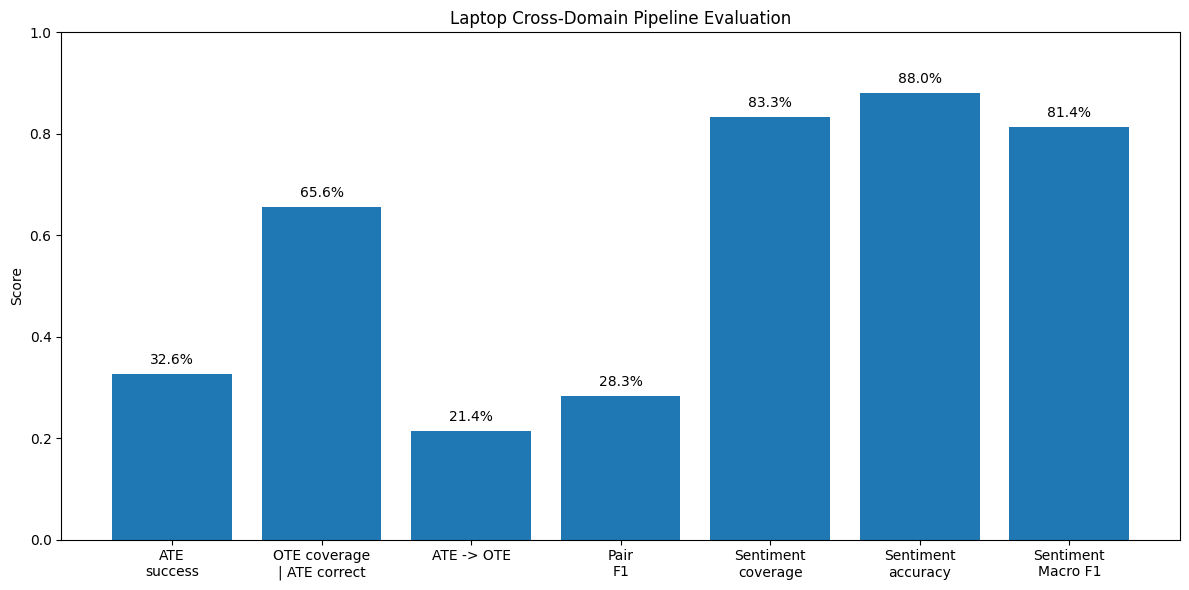

In [128]:
# Graph

labels = [
    "ATE\nsuccess",
    "OTE coverage\n| ATE correct",
    "ATE -> OTE",
    "Pair\nF1",
    "Sentiment\ncoverage",
    "Sentiment\naccuracy",
    "Sentiment\nMacro F1"
]
values = [
    laptop_ate_success,
    laptop_ote_coverage,
    laptop_eval_success,
    laptop_pair_f1,
    laptop_sentiment_coverage,
    laptop_sentiment_accuracy,
    laptop_f1_macro
]
plt.figure(figsize=(12, 6))
bars = plt.bar(labels, values)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Laptop Cross-Domain Pipeline Evaluation")
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.02,
        f"{value:.1%}",
        ha="center"
    )
plt.tight_layout()
plt.show()

# Domain comparison

In [129]:
domain_comparison = pd.DataFrame({
    "Metric": [
        "ATE Success",
        "OTE Coverage | ATE correct",
        "ATE -> OTE",
        "Aspect–Opinion Pair F1",
        "Sentiment Coverage | ATE correct",
        "Sentiment Accuracy",
        "Sentiment Macro F1"
    ],
    "Restaurants": [
        ate_success,
        ote_coverage,
        eval_success,
        f1,
        sentiment_coverage,
        sentiment_accuracy,
        f1_macro
    ],
    "Laptops": [
        laptop_ate_success,
        laptop_ote_coverage,
        laptop_eval_success,
        laptop_pair_f1,
        laptop_sentiment_coverage,
        laptop_sentiment_accuracy,
        laptop_f1_macro
    ]
})
domain_comparison

,Metric,Restaurants,Laptops
0,ATE Success,0.833333,0.326087
1,OTE Coverage | ATE correct,0.733333,0.655556
2,ATE -> OTE,0.611111,0.213768
3,Aspect–Opinion Pair F1,0.511628,0.282974
4,Sentiment Coverage | ATE correct,0.866667,0.833333
5,Sentiment Accuracy,0.846154,0.880000
6,Sentiment Macro F1,0.704678,0.813648


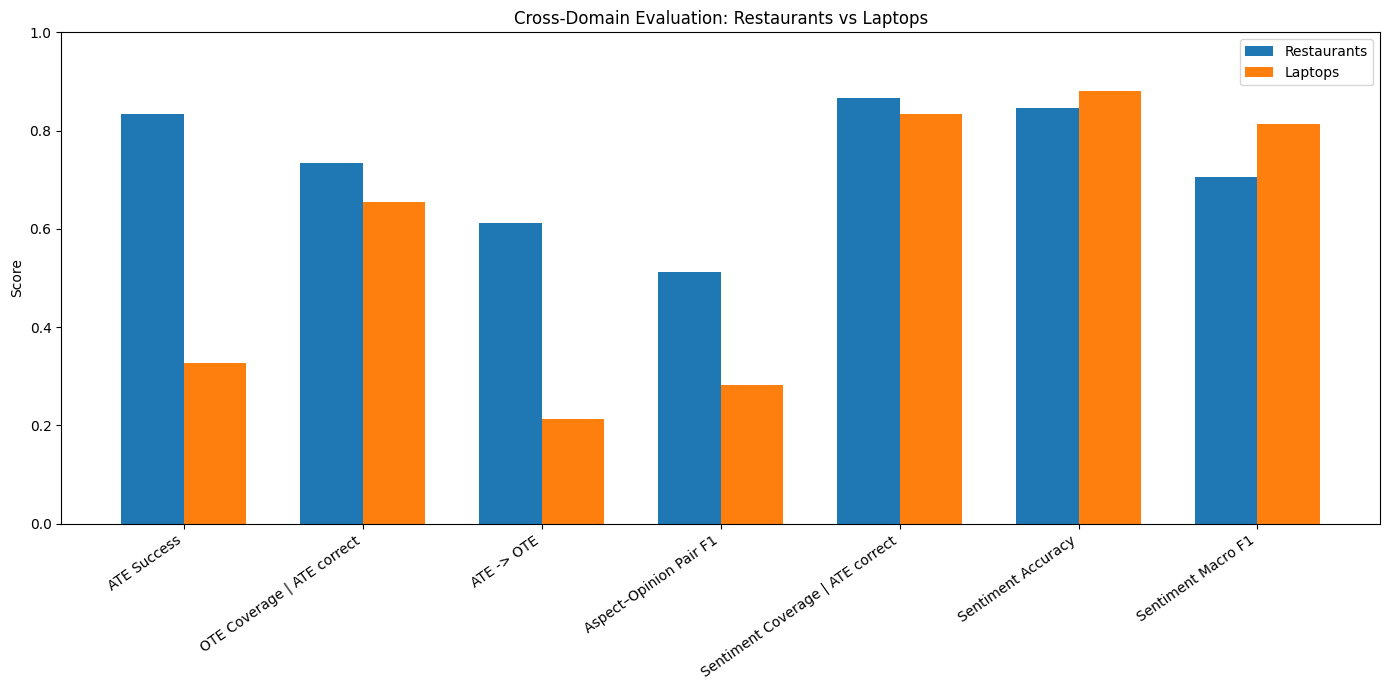

In [130]:
x = np.arange(
    len(domain_comparison)
)
width = 0.35


plt.figure(figsize=(14, 7))
plt.bar(
    x - width / 2,
    domain_comparison[
        "Restaurants"
    ],
    width,
    label="Restaurants"
)
plt.bar(
    x + width / 2,
    domain_comparison[
        "Laptops"
    ],
    width,
    label="Laptops"
)
plt.xticks(
    x,
    domain_comparison[
        "Metric"
    ],
    rotation=35,
    ha="right"
)
plt.ylim(
    0,
    1
)
plt.ylabel(
    "Score"
)
plt.title(
    "Cross-Domain Evaluation: Restaurants vs Laptops"
)
plt.legend()
plt.tight_layout()
plt.show()